In [77]:
%load_ext autoreload
%autoreload 2

import argparse
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import mplhep
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

from analysis.utils.datasets import CNNProjectionDataset
from analysis.utils.geometry import Geometry, get_rebinned_geometry
from analysis.utils.networks import ClassifierProjectionCNN
from analysis.utils.plot_utils import setup
from analysis.utils.torch_data_utils import evaluate_model
from analysis.utils.torch_utils import (
    get_device,
    load_weights,
    show_model,
    train,
)
from analysis.utils.truth import TruthParticle, get_truth_particle
from analysis.utils.units import um
from analysis.utils.utils import (
    get_figures_path,
    get_npy_path,
    get_parquet_path,
    get_torch_path,
    get_weights_path,
)
from analysis.utils.validation_utils import (
    get_accuracy_dict,
    plot_confusion_matrix,
    plot_precision_recall_curve,
    plot_probabilities,
    plot_roc_curve,
    plot_training_metrics,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [154]:
setup()

In [130]:
@dataclass
class NuType:
    idx: int
    label: str
    latex_name: str


nue = NuType(0, "nue", r"CC $\nu_{e}$")
num = NuType(1, "num", r"CC $\nu_{\mu}$")
nun = NuType(2, "nun", "NC")
nus = [nue, num, nun]

In [1]:
feature_dim: int = 128
# geometry_label = "cnn_projection_200um_bins_10000_10003"
# geometry_label = "theta_100mrad_ratio_10"
geometry_label = "./"
torch_path = get_torch_path() / geometry_label / "cnn.pt"
weights_path = get_weights_path() / geometry_label
figures_path = get_figures_path() / geometry_label

dataset = torch.load(torch_path, weights_only=False, map_location="cpu")

_, test_indices = train_test_split(
    range(len(dataset)), test_size=0.1, random_state=42, stratify=dataset.labels
)
test_dataset = torch.utils.data.subset(dataset, test_indices)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, pin_memory=True)

device = get_device()

model = ClassifierProjectionCNN(feature_dim=feature_dim, num_classes=3)
model = model.to(device)

load_weights(model, device, weights_path / "model_weights.pth")

NameError: name 'get_torch_path' is not defined

In [ ]:
y_true, y_pred, y_prob = evaluate_model(
    model=model, test_loader=test_loader, device=device
)

Evaluating: 100%|██████████| 167/167 [00:25<00:00,  6.44it/s]


In [ ]:
acc_dict = get_accuracy_dict(
    y_true=y_true, y_pred=y_pred, class_names=[nu.label for nu in nus]
)
for label, acc in acc_dict.items():
    print(f"{label}: {acc * 100:.1f}%")

nue: 75.9%
num: 74.2%
nun: 72.4%
average: 74.2%


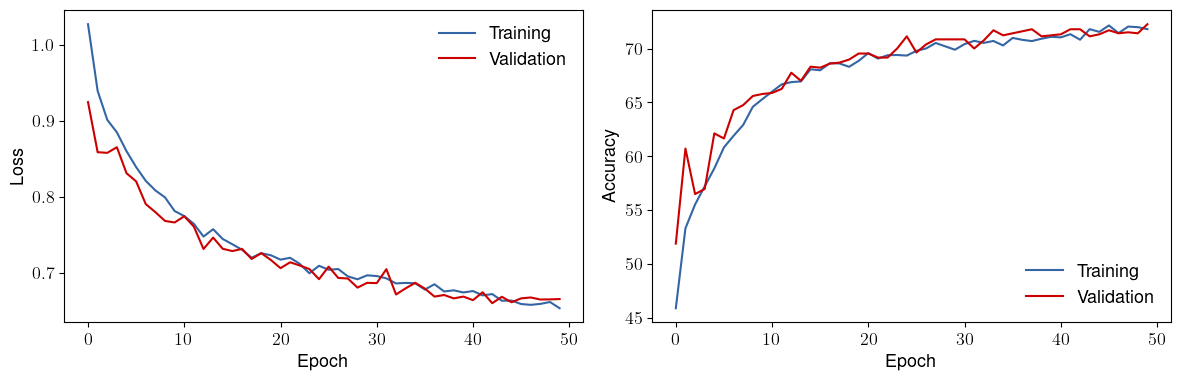

In [ ]:
plot_training_metrics(weights_path / "training_metrics.npz")

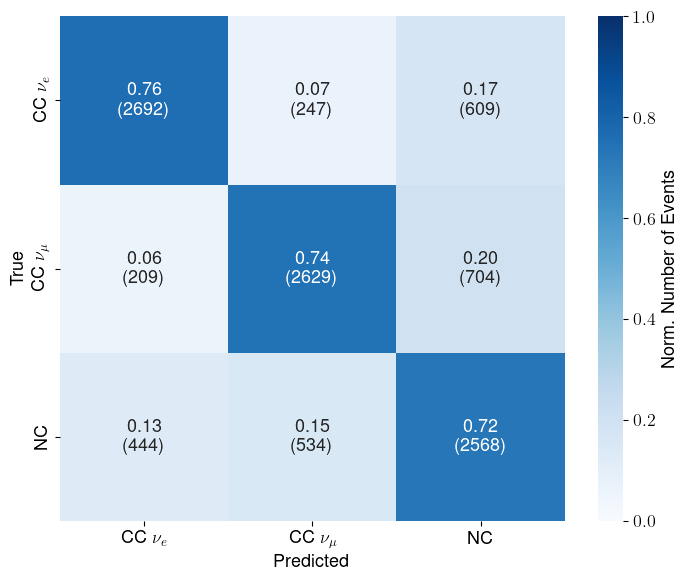

In [ ]:
plot_confusion_matrix(
    y_true, y_pred, normalize=True, class_names=[nu.latex_name for nu in nus]
)

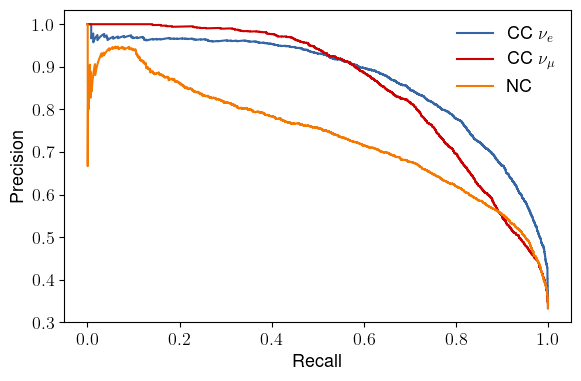

In [ ]:
plot_precision_recall_curve(
    y_true=y_true, y_prob=y_prob, class_names=[nu.latex_name for nu in nus]
)

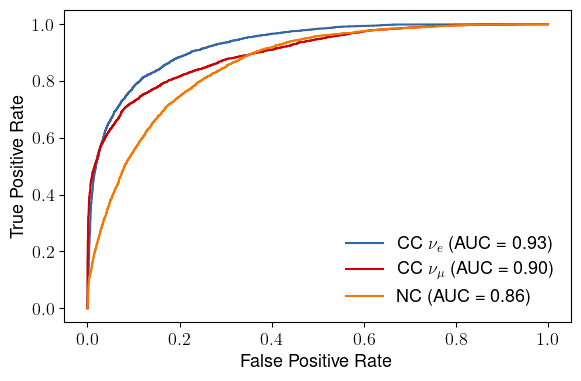

In [ ]:
plot_roc_curve(
    y_true=y_true,
    y_prob=y_prob,
    class_names=[nu.latex_name for nu in nus],
    figure_path=figures_path / "roc_curve.png",
)

3548.0
3548.0
3548.0


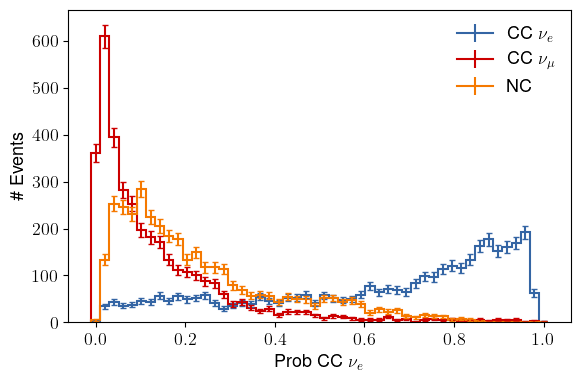

3542.0
3542.0
3542.0


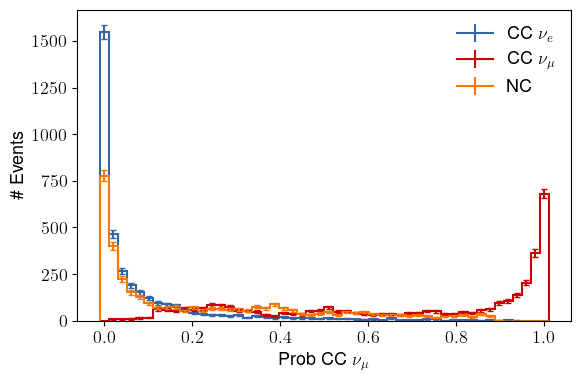

3546.0
3546.0
3546.0


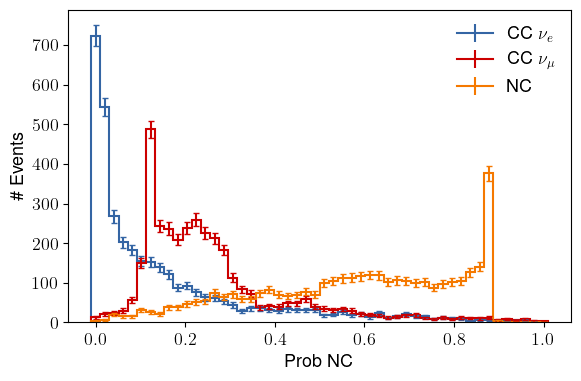

In [ ]:
plot_probabilities(
    y_true=y_true, y_prob=y_prob, class_names=[nu.latex_name for nu in nus]
)

In [ ]:
truth_df = pd.read_parquet(get_torch_path() / "cnn_projection_truth.parq")

In [ ]:
truth_df.loc[:, "E_nu_bin"] = pd.cut(
    truth_df["E_nu"], bins=np.arange(0, 1200e3 + 1e-3, 100e3), labels=False
)

In [ ]:
num_events = len(dataset)
e_nu = np.zeros(num_events)
for i in range(num_events):
    e_nu[i] = dataset[i][1]["E_nu"]
e_nu = np.array(e_nu)

In [ ]:
nu_energy_edges = np.arange(0, 1200e3 + 1e-3, 100e3)
nu_energy_centers = (nu_energy_edges[:-1] + nu_energy_edges[1:]) / 2
e_nu_bins = pd.cut(e_nu, bins=nu_energy_edges, labels=False)

In [ ]:
acc_dicts = []
for i in range(12):
    bin_indices = indices = np.where(e_nu_bins == i)[0]
    y_true_bin = y_true[bin_indices]
    y_pred_bin = y_pred[bin_indices]
    acc_dict = get_accuracy_dict(
        y_true=y_true_bin, y_pred=y_pred_bin, class_names=[nu.label for nu in nus]
    )
    acc_dicts.append(acc_dict)

In [ ]:
combined_acc_dict = {}
for key in ["nue", "num", "nun", "average"]:
    combined_acc_dict[key] = [acc_dict[key] for acc_dict in acc_dicts]
acc_df = pd.DataFrame(combined_acc_dict)
acc_df.loc[:, "energy"] = nu_energy_centers * 1e-3

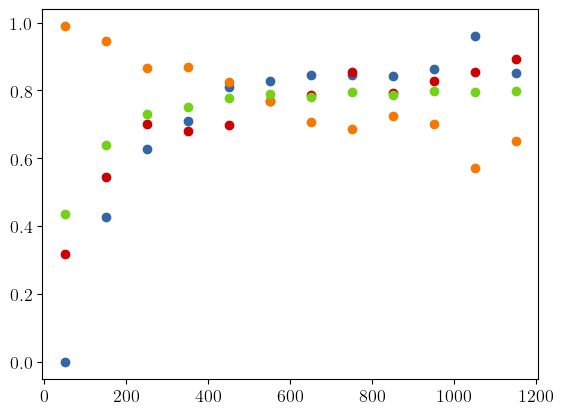

In [ ]:
fig, ax = plt.subplots()
for key in ["nue", "num", "nun", "average"]:
    plt.scatter(acc_df["energy"], acc_df[key])

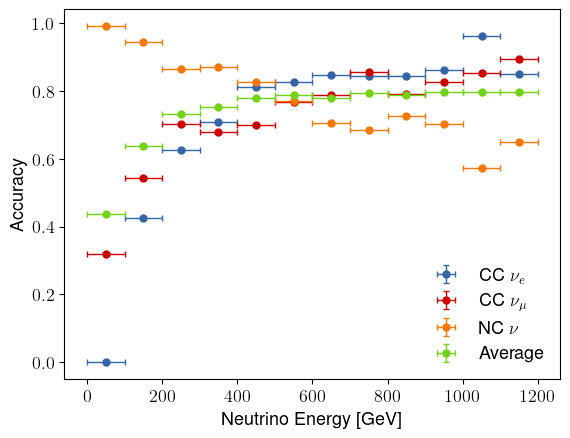

In [ ]:
fig, ax = plt.subplots()
for key, label in zip(
    ["nue", "num", "nun", "average"],
    [r"CC $\nu_e$", r"CC $\nu_\mu$", r"NC $\nu$", "Average"],
):
    mplhep.histplot(
        acc_df[key].values,
        bins=nu_energy_edges * 1e-3,
        histtype="errorbar",
        xerr=True,
        label=label,
    )
ax.legend()
ax.set_xlabel(r"Neutrino Energy [GeV]")
ax.set_ylabel("Accuracy")
plt.show()

In [ ]:
event_indices = np.arange(len(test_dataset))
bad_event_dict = {
    "nue_nue": event_indices[(y_true == 0) & (y_pred == 0)],
    "nue_num": event_indices[(y_true == 0) & (y_pred == 1)],
    "nue_nun": event_indices[(y_true == 0) & (y_pred == 2)],
    "num_nue": event_indices[(y_true == 1) & (y_pred == 0)],
    "num_num": event_indices[(y_true == 1) & (y_pred == 1)],
    "num_nun": event_indices[(y_true == 1) & (y_pred == 2)],
    "nun_nue": event_indices[(y_true == 2) & (y_pred == 0)],
    "nun_num": event_indices[(y_true == 2) & (y_pred == 1)],
    "nun_nun": event_indices[(y_true == 2) & (y_pred == 2)],
}

for key, indices in bad_event_dict.items():
    print(f"{key}: {len(indices)}")

nue_nue: 2692
nue_num: 247
nue_nun: 609
num_nue: 209
num_num: 2629
num_nun: 704
nun_nue: 444
nun_num: 534
nun_nun: 2568


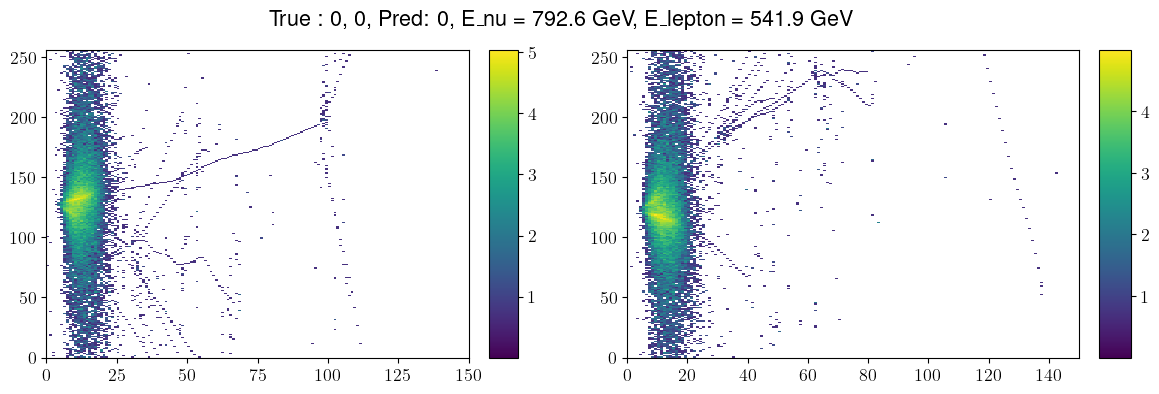

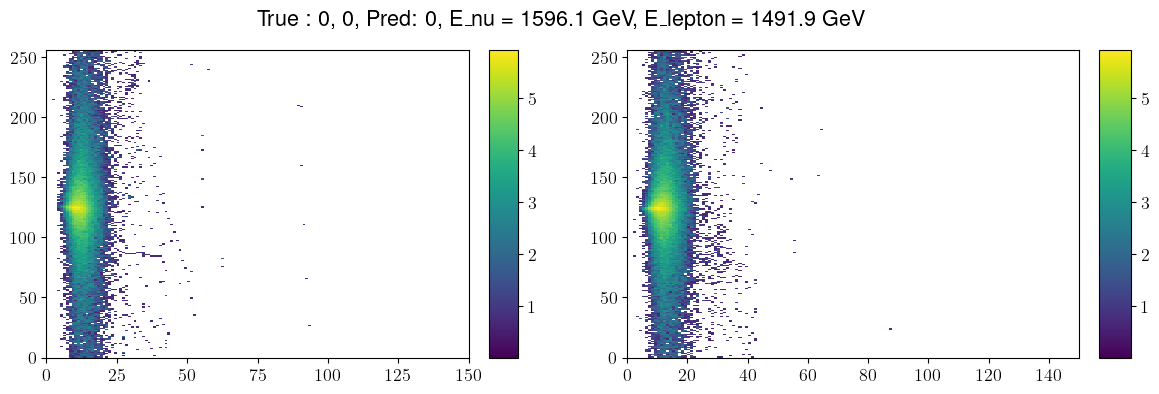

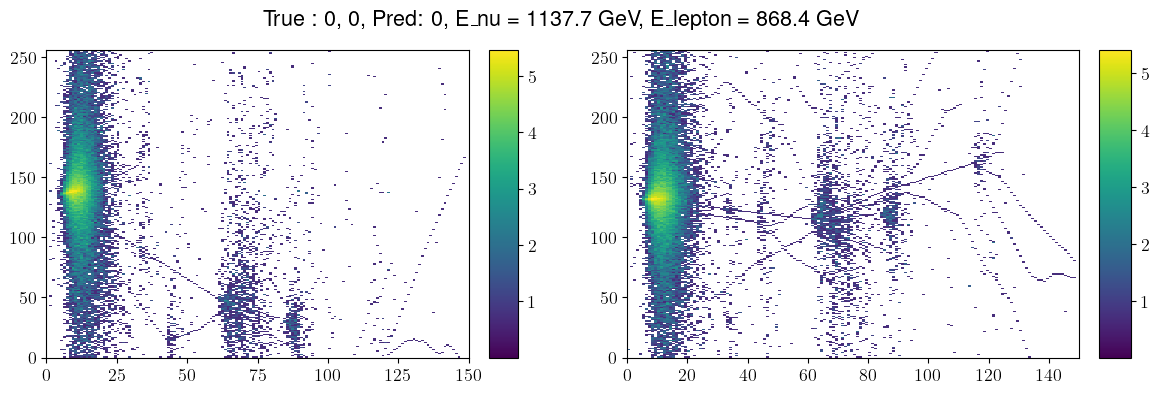

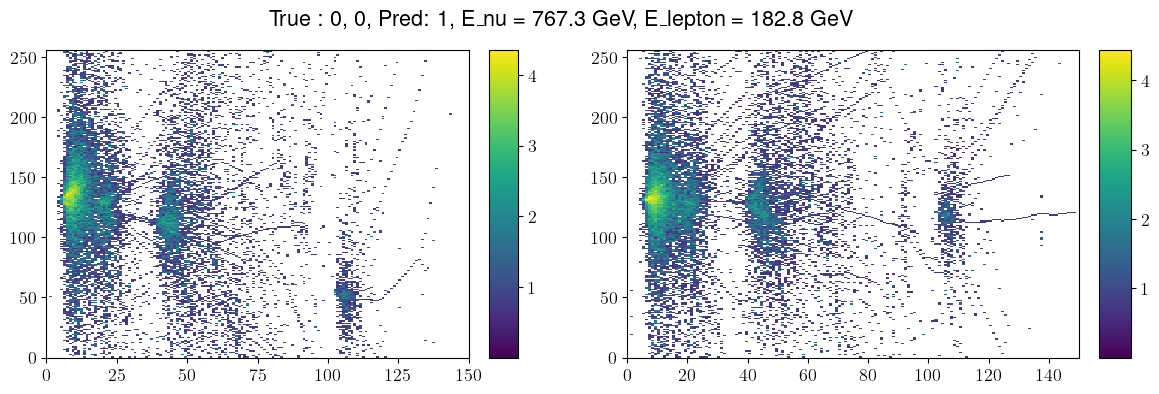

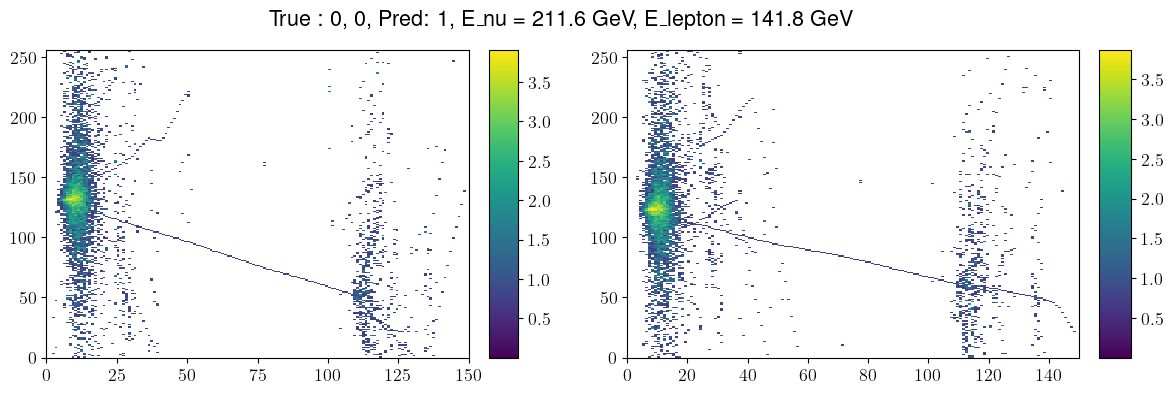

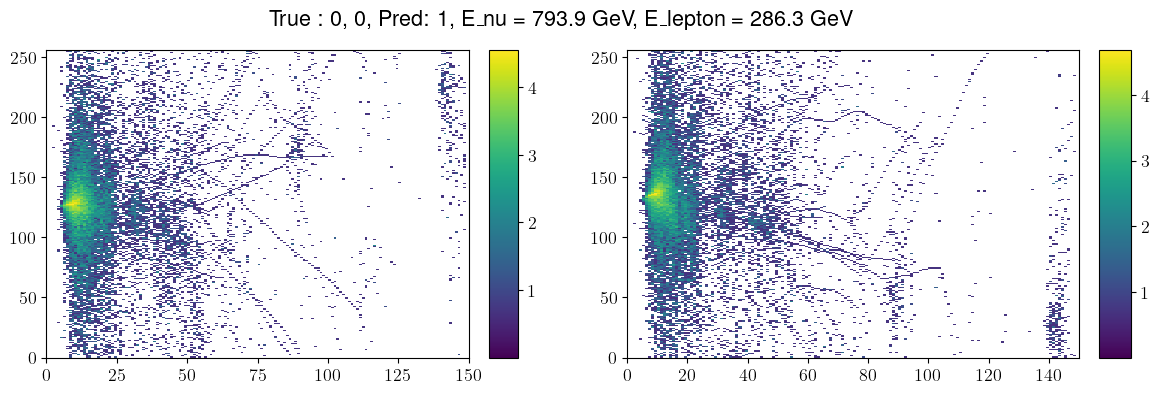

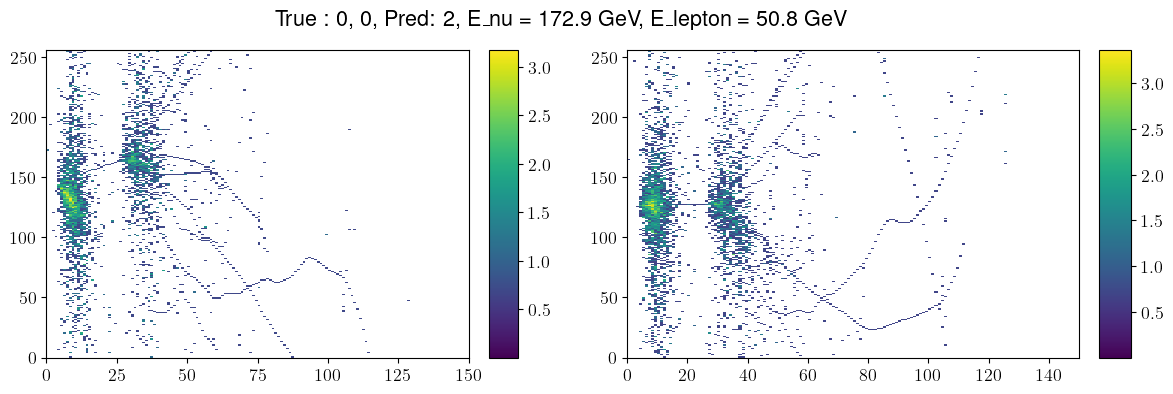

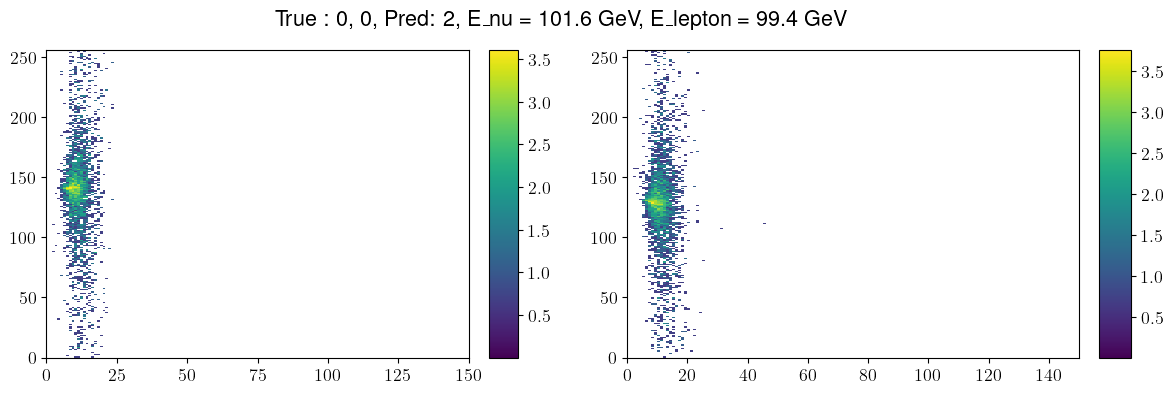

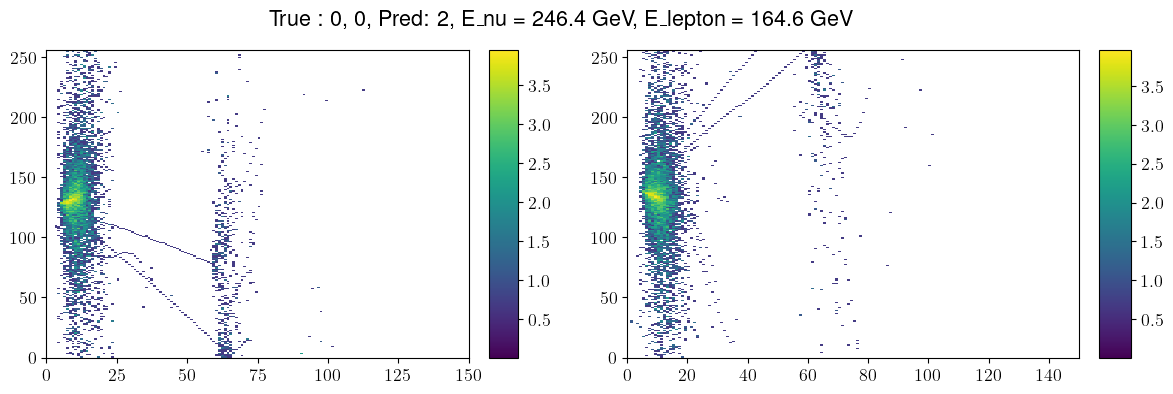

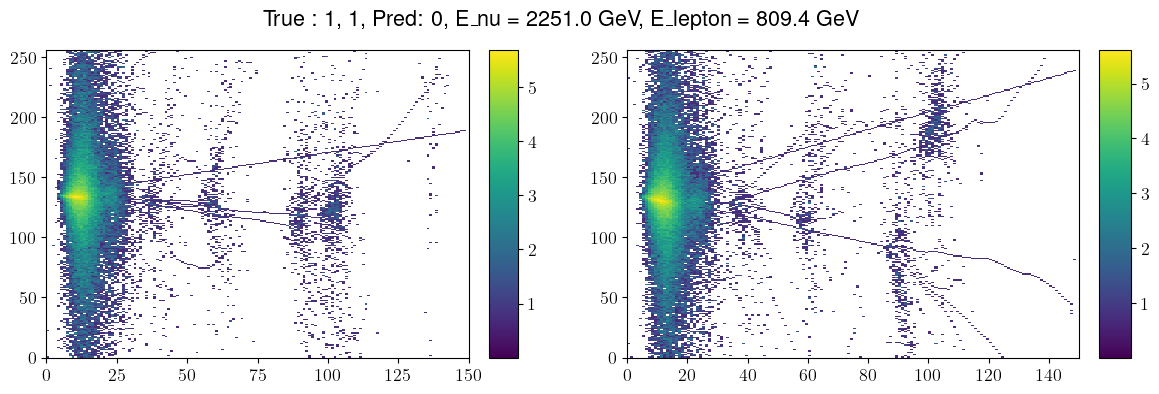

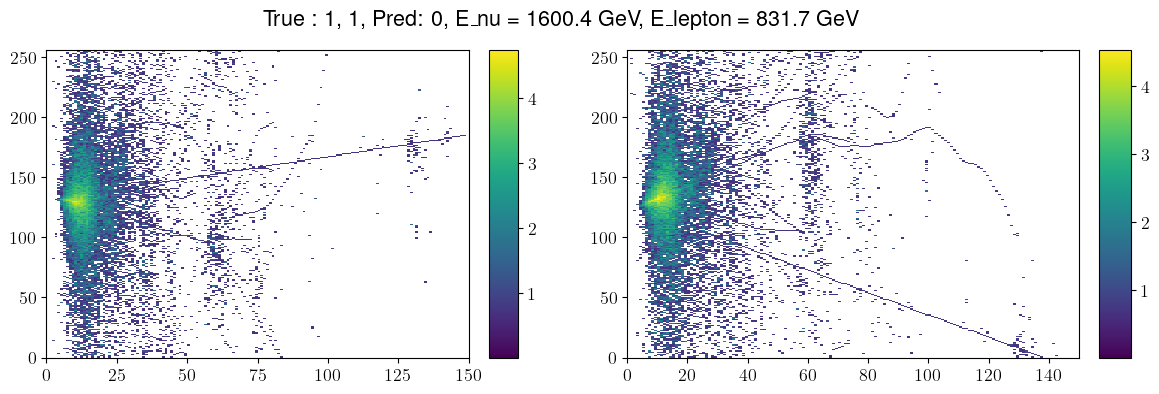

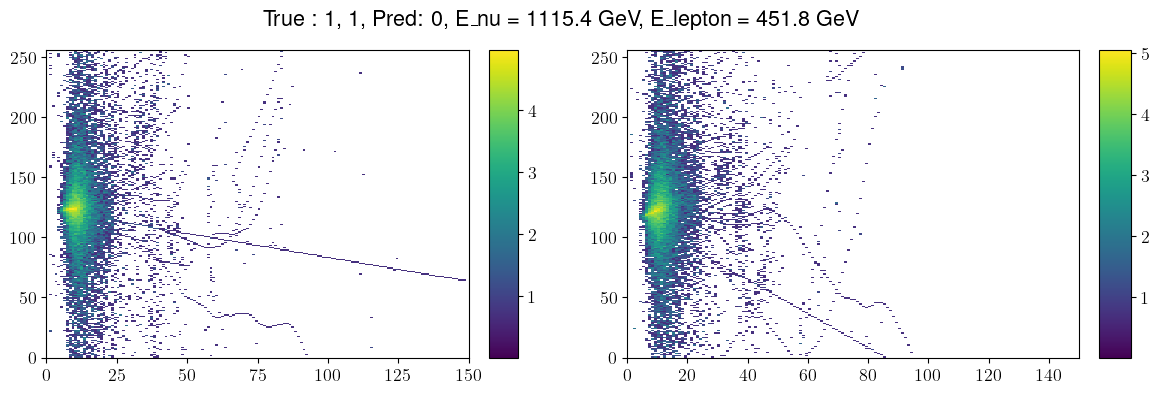

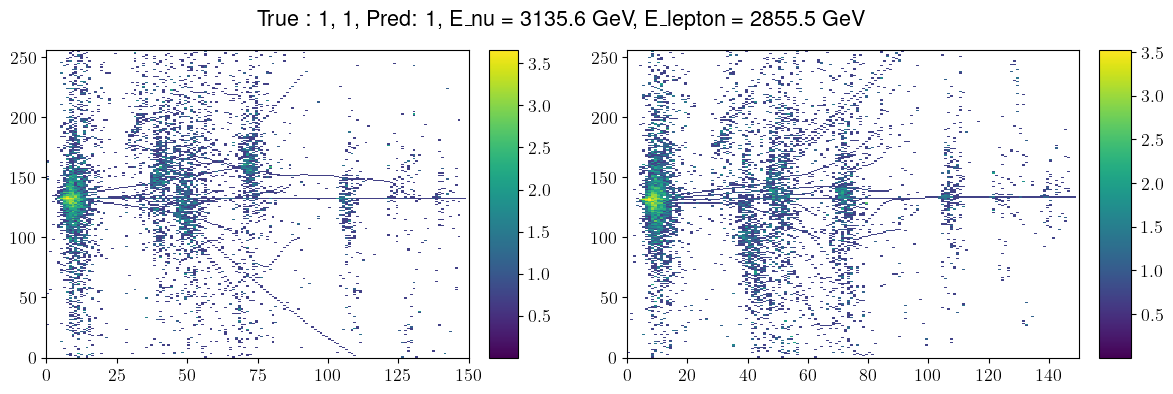

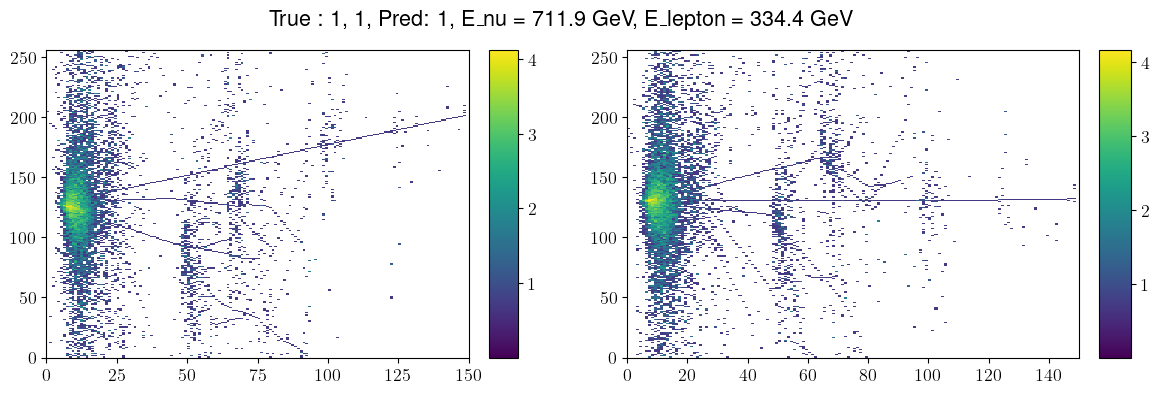

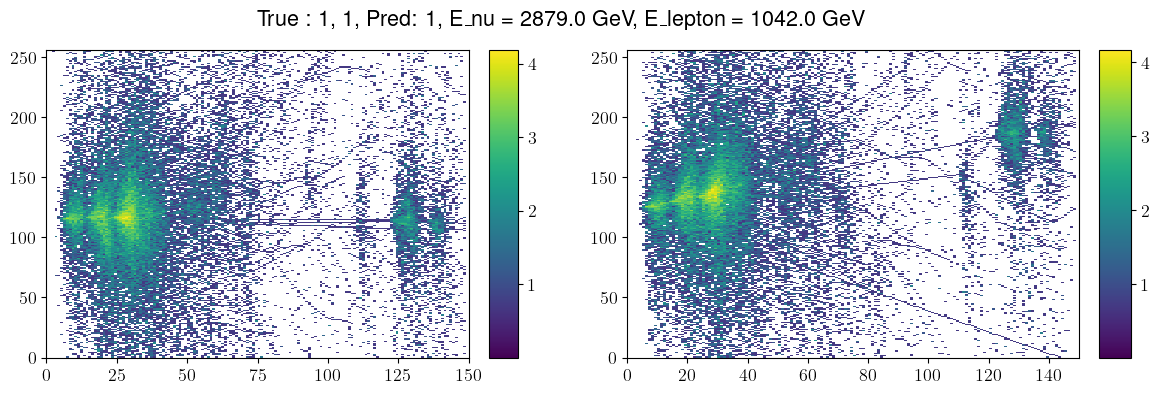

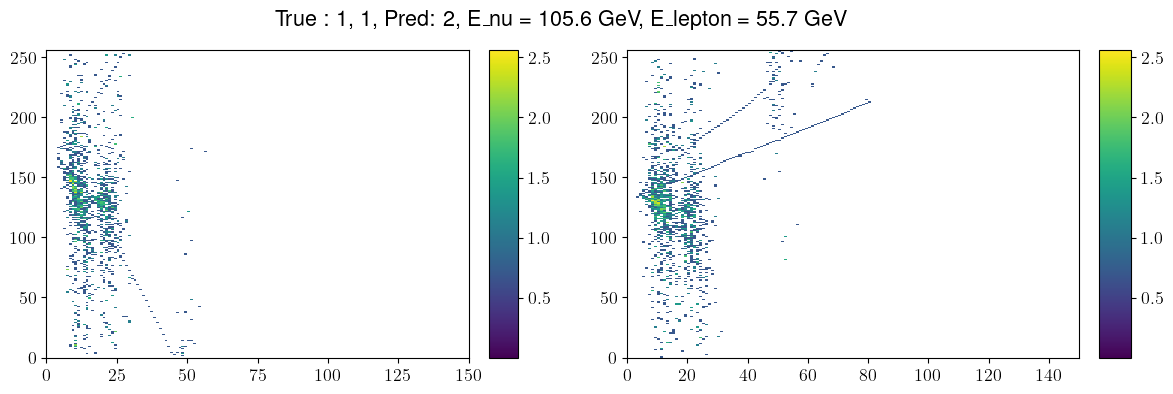

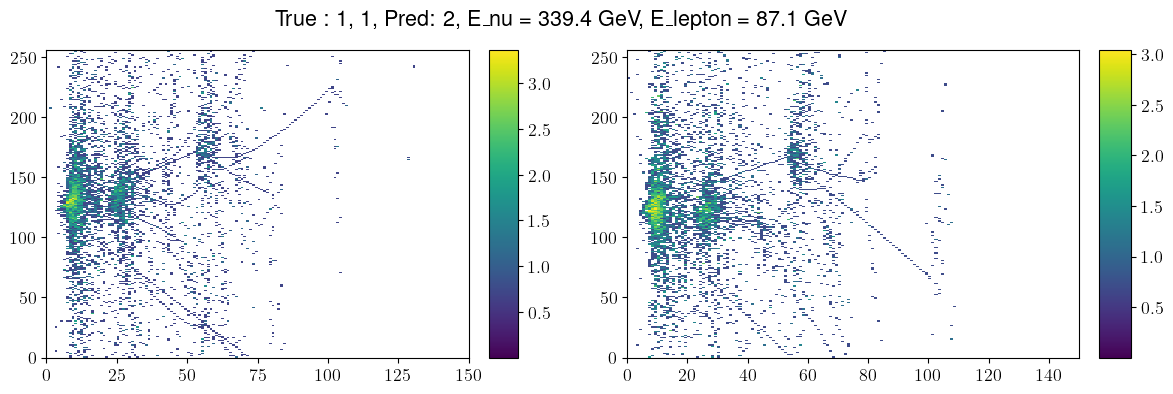

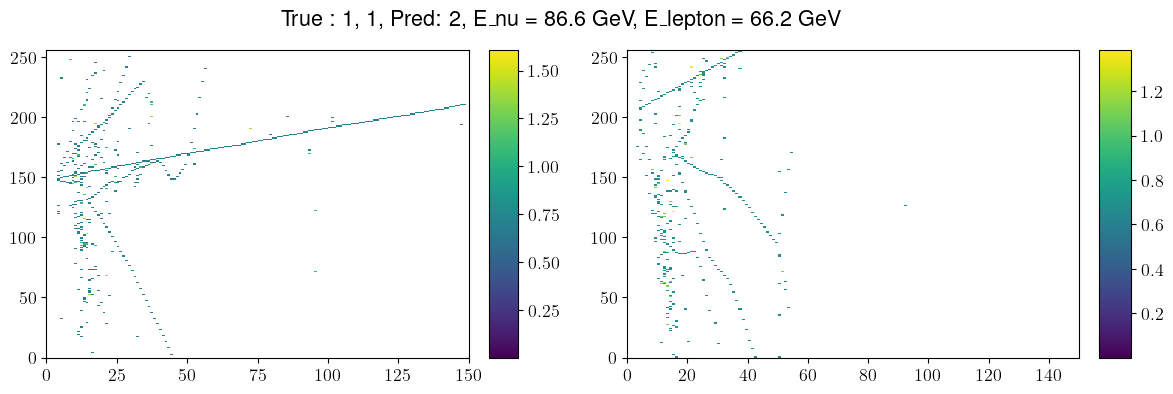

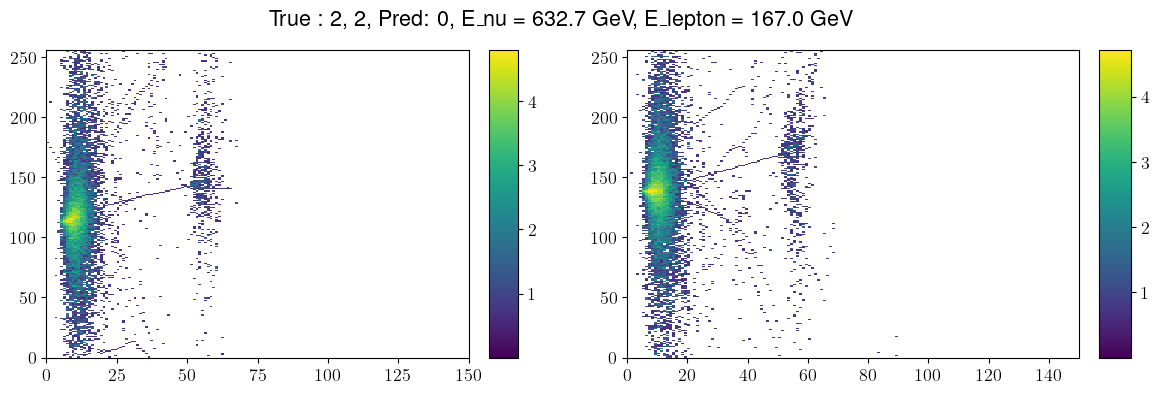

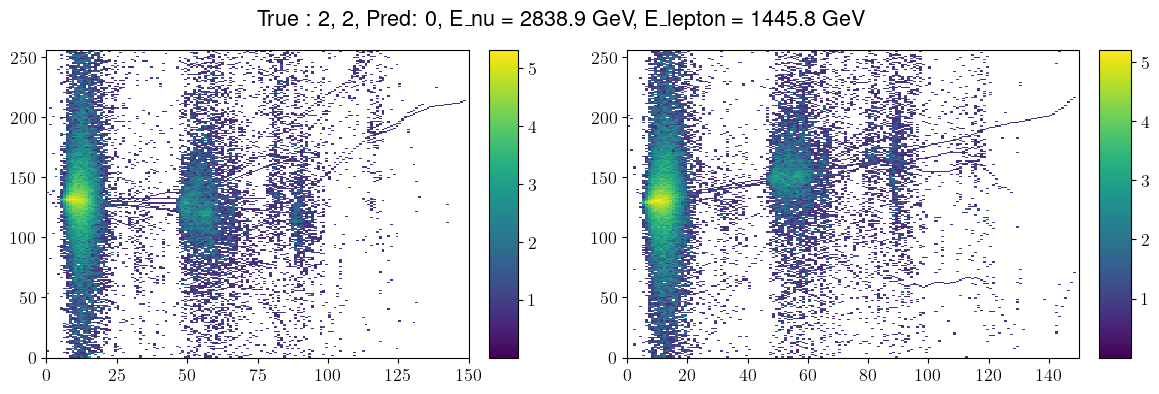

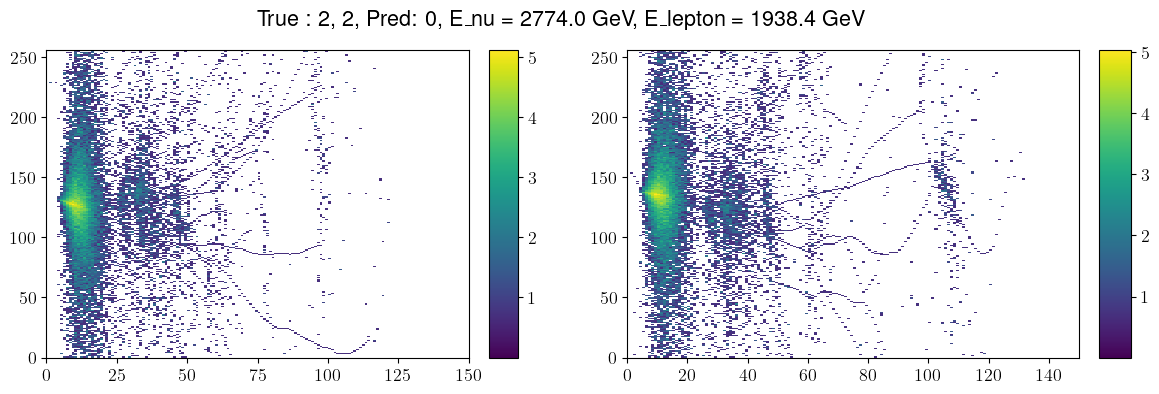

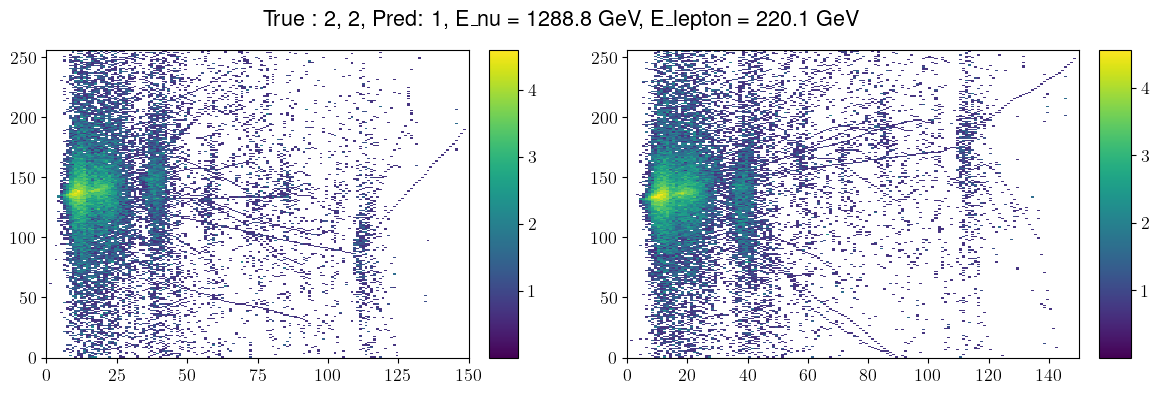

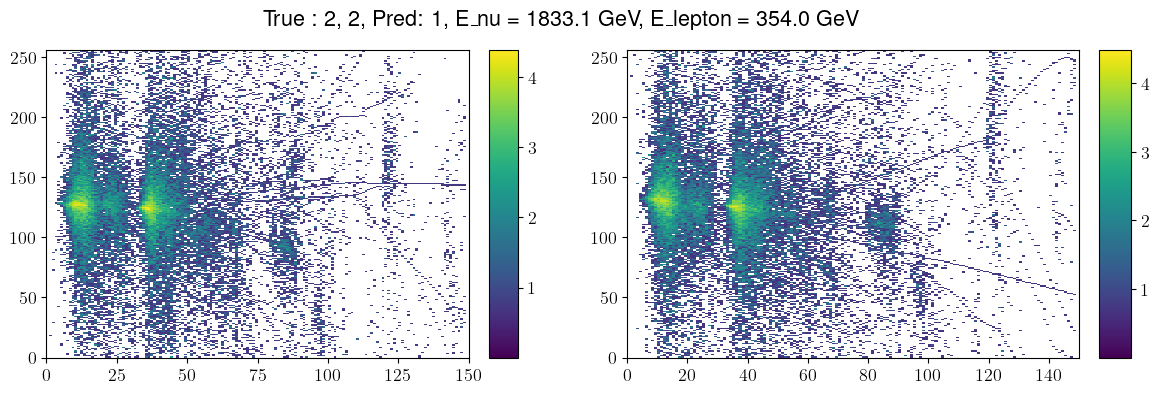

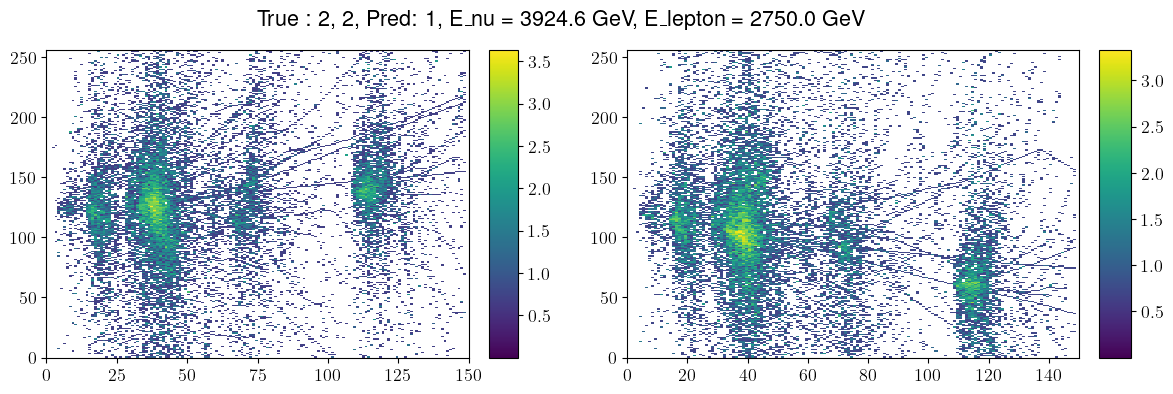

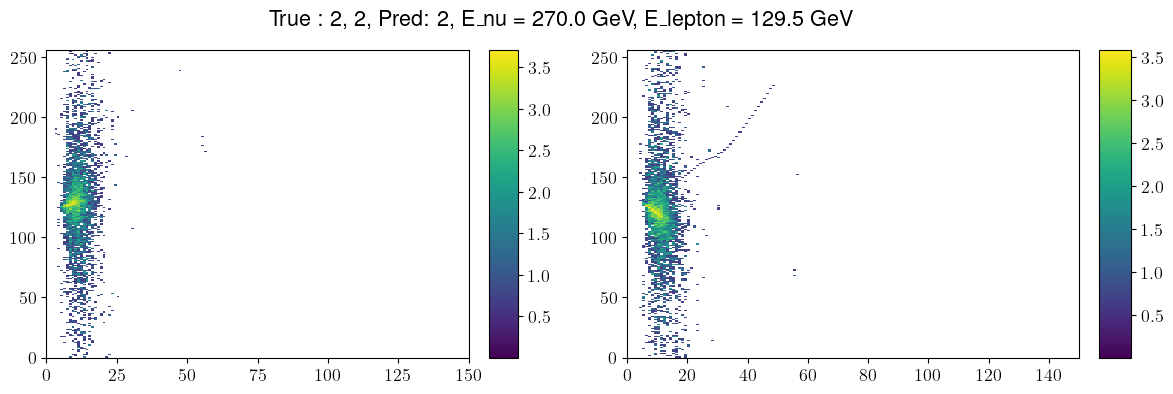

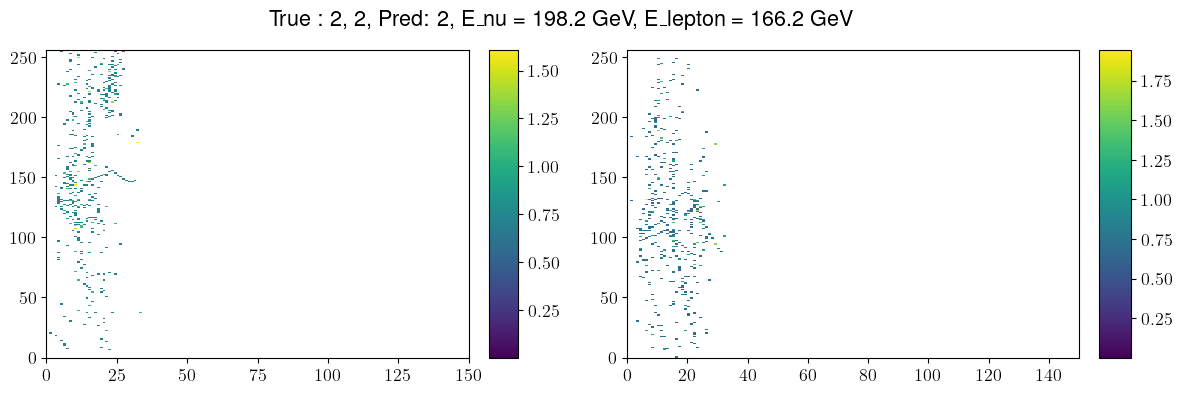

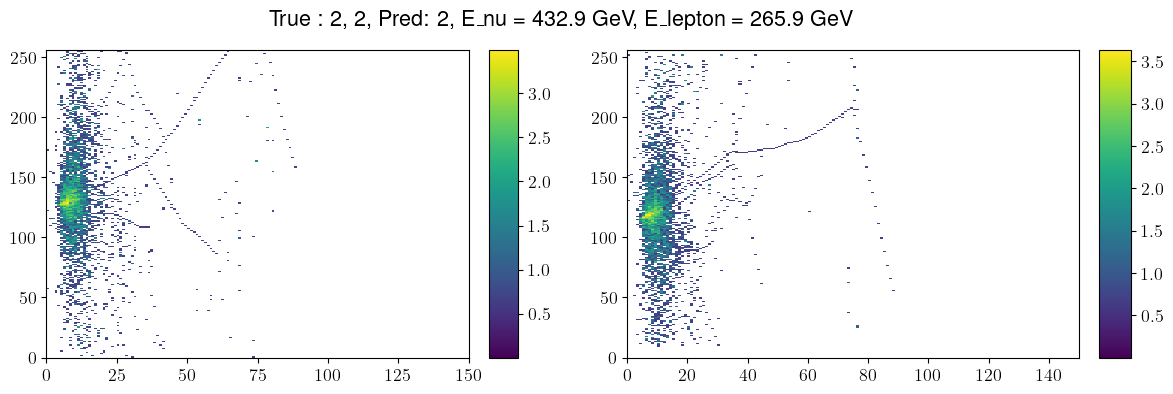

In [ ]:
for key, indices in bad_event_dict.items():
    for idx in indices[:3]:
        fig, axs = plt.subplots(1, 2, figsize=(2 * 6, 4))
        (zx, zy), truth = dataset[idx]
        plt.suptitle(
            f"True : {truth['label']}, {y_true[idx]}, Pred: {y_pred[idx]}, E_nu = {truth['E_nu'] * 1e-3:.1f} GeV, E_lepton = {truth['E_lepton'] * 1e-3:.1f} GeV"
        )
        for i, proj in enumerate([zx, zy]):
            proj = proj.cpu().numpy()[0]
            mplhep.hist2dplot(proj, cmin=1e-3, ax=axs[i])
        plt.show()
